In [121]:
from pathlib import Path
import pandas as pd

import numpy as np
import cv2
from skimage.graph import route_through_array
from scipy.ndimage import distance_transform_edt


In [122]:

def index_segmentations_df(root_dir):
    root_dir = Path(root_dir)
    images_root = root_dir / "images"
    masks_root = root_dir / "masks"

    records = []

    for scan_dir in images_root.iterdir():
        if not scan_dir.is_dir():
            continue

        scan_name = scan_dir.name

        for class_dir in scan_dir.iterdir():
            if not class_dir.is_dir():
                continue

            class_name = class_dir.name

            for img_path in class_dir.iterdir():
                if img_path.suffix.lower() not in [".png", ".jpg", ".tif", ".tiff"]:
                    continue

                mask_path = masks_root / scan_name / class_name / img_path.name

                if not mask_path.exists():
                    raise FileNotFoundError(f"Missing mask for {img_path}")

                records.append({
                    "scan": scan_name,
                    "class": class_name,
                    "image_path": img_path,
                    "mask_path": mask_path,
                })

    df = pd.DataFrame(records)

    # Optional: sort for reproducibility
    df = df.sort_values(
        by=["scan", "class", "image_path"],
        ignore_index=True
    )

    return df


In [123]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path

def show_row_visuals(
    df,
    idx,
    columns,
    cmap_mask="gray"
):
    """
    Show original image + multiple masks/images side by side.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing image/mask columns
    idx : int
        Row index in the DataFrame
    columns : list[str]
        Columns to visualize (can be paths or numpy arrays)
        e.g. ["mask_path", "true_mask"]
    cmap_mask : str
        Colormap for mask-like visuals
    """
    row = df.iloc[idx]

    # Always load original image
    image = np.array(Image.open(row.image_path).convert("RGB"))

    n_plots = 1 + len(columns)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

    if n_plots == 1:
        axes = [axes]

    # --- Original image ---
    axes[0].imshow(image)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    # --- Additional columns ---
    for ax, col in zip(axes[1:], columns):
        value = row[col]

        # Case 1: numpy array (e.g. computed mask)
        if isinstance(value, np.ndarray):
            ax.imshow(value, cmap=cmap_mask)

        # Case 2: path to image/mask
        elif isinstance(value, (str, Path)):
            arr = np.array(Image.open(value))
            if arr.ndim == 2:
                ax.imshow(arr, cmap=cmap_mask)
            else:
                ax.imshow(arr)

        else:
            raise TypeError(f"Unsupported type for column '{col}': {type(value)}")

        ax.set_title(col)
        ax.axis("off")

    plt.suptitle(
        f"Scan: {row.scan} | Class: {row['class']}",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()


In [124]:
def compute_similarity_cost_rgb(image):
    img = image.astype(np.float32)

    dx = np.linalg.norm(
        img[:, 1:] - img[:, :-1],
        axis=-1
    )
    dx = np.pad(dx, ((0, 0), (1, 0)))

    dy = np.linalg.norm(
        img[1:, :] - img[:-1, :],
        axis=-1
    )
    dy = np.pad(dy, ((1, 0), (0, 0)))

    cost = dx + dy
    cost = cost / (cost.max() + 1e-6)
    cost += 1e-3

    return cost

In [125]:
def compute_similarity_cost_gray(gray, white_penalty=10.0):
    gray = gray.astype(np.float32)

    dx = np.abs(gray[:, 1:] - gray[:, :-1])
    dx = np.pad(dx, ((0, 0), (1, 0)))

    dy = np.abs(gray[1:, :] - gray[:-1, :])
    dy = np.pad(dy, ((1, 0), (0, 0)))

    similarity = dx + dy
    similarity = similarity / (similarity.max() + 1e-6)

    # Penalize bright pixels (white background)
    brightness = gray / 255.0
    brightness_penalty = 1.0 + white_penalty * (brightness ** 2)

    cost = similarity * brightness_penalty
    cost += 1e-3

    return cost


In [126]:
def draw_thick_path(
    base_mask,
    path_pixels,
    thickness_map,
    min_radius=1,
    max_radius=10,
):
    """
    Draw a path whose thickness adapts to local component thickness.
    """

    H, W = base_mask.shape
    out = base_mask.copy()

    for y, x in path_pixels:
        r = int(np.clip(thickness_map[y, x], min_radius, max_radius))
        cv2.circle(out, (x, y), r, 1, -1)

    return out


In [127]:
def keep_largest_component(binary_mask):
    num_labels, labels = cv2.connectedComponents(binary_mask)

    if num_labels <= 2:
        return binary_mask

    max_area = 0
    max_label = 1

    for label in range(1, num_labels):
        area = np.sum(labels == label)
        if area > max_area:
            max_area = area
            max_label = label

    return (labels == max_label).astype(np.uint8)


In [128]:
def connect_components_geodesic_similarity(
    binary_mask,
    image,
    min_component_frac=0.0005,
    restrict_to_mask=True,
    thickness_scale=1.0,
    max_radius=12,
):
    connected_mask = binary_mask.copy()

    H, W = binary_mask.shape
    image_area = H * W
    min_area_px = min_component_frac * image_area

    num_labels, labels = cv2.connectedComponents(binary_mask)
    if num_labels <= 2:
        return connected_mask

    # --- Cost computation ---
    if image.ndim == 3:
        cost = compute_similarity_cost_rgb(image)
    elif image.ndim == 2:
        cost = compute_similarity_cost_gray(image)
    else:
        raise ValueError(f"Unsupported image shape: {image.shape}")

    if restrict_to_mask:
        penalty = cost.max() * 10
        cost[~binary_mask.astype(bool)] += penalty

    # --- Thickness estimation ---
    thickness_map = distance_transform_edt(binary_mask) * thickness_scale

    # --- Collect large components ---
    components = []
    for label in range(1, num_labels):
        ys, xs = np.where(labels == label)
        area = len(xs)

        if area < min_area_px:
            continue

        cy = int(np.mean(ys))
        cx = int(np.mean(xs))
        components.append((cy, cx))

    # Nothing to connect
    if len(components) < 2:
        # Still enforce single component
        return keep_largest_component(connected_mask)

    # Sort components spatially
    components = sorted(components, key=lambda p: (p[1], p[0]))

    # --- Connect components ---
    for i in range(len(components) - 1):
        start = components[i]
        end = components[i + 1]

        path, _ = route_through_array(
            cost,
            start,
            end,
            fully_connected=True
        )

        connected_mask = draw_thick_path(
            connected_mask,
            path,
            thickness_map,
            min_radius=1,
            max_radius=max_radius,
        )

    # --- FINAL CLEANUP: keep only one connected component ---
    connected_mask = keep_largest_component(connected_mask)

    return connected_mask.astype(np.uint8)


In [129]:
def compute_mask_otsu_inside_annotation(
    image_path,
    mask_path,
    connect_components=True,
):
    image = np.array(Image.open(image_path).convert("RGB"))
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    orig_mask = np.array(Image.open(mask_path)) > 0

    roi = gray.copy()
    roi[~orig_mask] = 255

    _, thresh = cv2.threshold(
        roi, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    mask = (thresh & orig_mask).astype(np.uint8)

    if connect_components:
        mask = connect_components_geodesic_similarity(mask, gray)

    return mask


In [130]:
def add_true_mask_column(df):
    df = df.copy()

    df["true_mask"] = df.apply(
        # lambda row: compute_brown_red_mask_hsv_adaptive(
        #     row.image_path,
        #     row.mask_path
        # ),
        lambda row: compute_mask_otsu_inside_annotation(
            row.image_path,
            row.mask_path
        ),
        axis=1
    )

    return df


Read annotation data

1009 annotation pairs found
Index(['scan', 'class', 'image_path', 'mask_path'], dtype='object')


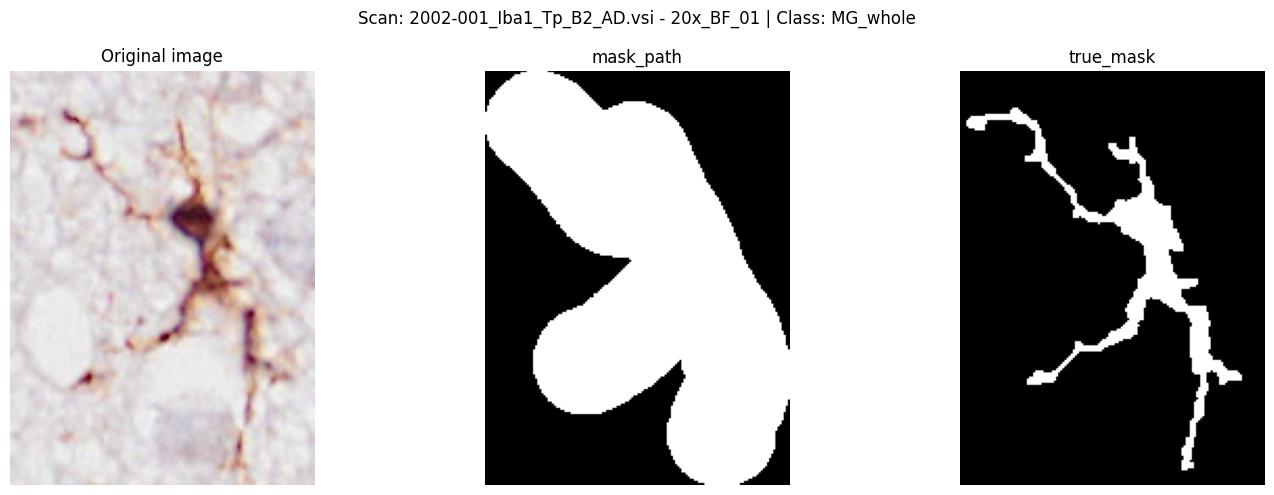

In [131]:
df = index_segmentations_df(
    r"C:\Users\chris\Desktop\University\Thesis\AnnotationsData\Segmentations"
)

# Only include the whole cell annotation for now, later we can do a custom soma segmentation
df = df[df['class'] == 'MG_whole']
print(len(df), "annotation pairs found")
df.head()

print(df.columns)



df = add_true_mask_column(df)
show_row_visuals(df, 1, columns = ["mask_path", 'true_mask'])
